   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40   
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40   
3             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E   
4             5  2013-12-03       Falcon 9  3170.000000   GTO  CCAFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
0    None None        1     False   False  False        NaN    1.0   
1    None None        1     False   False  False        NaN    1.0   
2    None None        1     False   False  False        NaN    1.0   
3  False Ocean        1     False   False  False        NaN    1.0   
4    None None        1     False   False  False        NaN    1.0   

   ReusedCount Serial   Longitude   Latitude  Class  
0            0  B0003  -80.577366  28.561857      

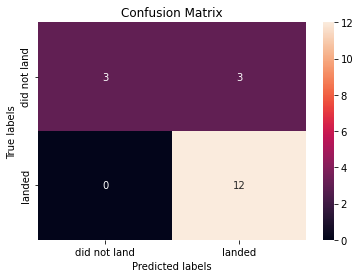

Tuned hyperparameters (best parameters) for SVM: {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
Accuracy for SVM (during validation): 0.8342857142857142
Accuracy on test data for SVM: 0.8333333333333334


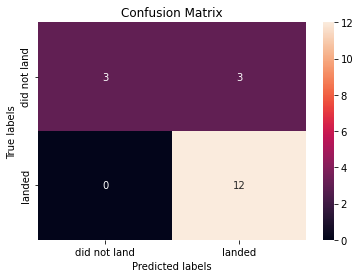

Tuned hyperparameters (best parameters) for Decision Tree: {'criterion': 'entropy', 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'random'}
Accuracy for Decision Tree (during validation): 0.8619047619047618
Accuracy on test data for Decision Tree: 0.7222222222222222


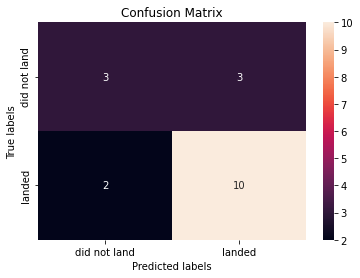

Tuned hyperparameters (best parameters) for KNN: {'algorithm': 'auto', 'n_neighbors': 4, 'p': 1}
Accuracy for KNN (during validation): 0.819047619047619
Accuracy on test data for KNN: 0.7222222222222222


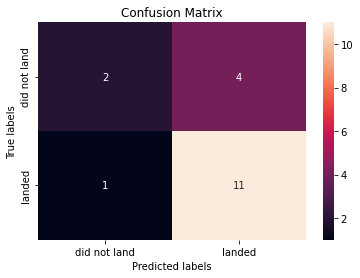

Classification Report for Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18

Classification Report for SVM:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18

Classification Report for Decision Tree:
               precision    recall  f1-score   support

           0       0.60      0.50      0.55         6
           1       0.77      0.83      0.80        12

    accuracy                           0.72        18
   mac

In [21]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import requests  # For fetching data
import io  # For StringIO

# Function to plot the confusion matrix
def plot_confusion_matrix(y, y_predict, labels=['did not land', 'landed']):
    """This function plots the confusion matrix."""
    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax, fmt='d')  # fmt='d' for integer annotation
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels(labels)
    ax.yaxis.set_ticklabels(labels)
    plt.show()

# Fetching the data from URL using requests
URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
response = requests.get(URL1)

# Check if the request was successful
if response.status_code == 200:
    # Load the data into a pandas DataFrame
    data = pd.read_csv(io.StringIO(response.text))
    print(data.head())  # Display first few rows of the dataset
    print(data.describe())  # Summary statistics
    print(data.isnull().sum())  # Check for missing values
else:
    print(f"Failed to fetch data: {response.status_code}")

# Create the target variable Y from the 'Class' column
Y = data['Class'].to_numpy()

# Preprocess the features
# Dropping non-numeric columns
X = data.drop(columns=['Class', 'Date', 'BoosterVersion', 'LandingPad', 'Outcome'])

# One-hot encoding for categorical variables
X = pd.get_dummies(X, drop_first=True)

# Check for missing values
print(X.isnull().sum())  # Check if there are still any missing values

# Preprocess the features (Standardization)
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# --- Logistic Regression ---
parameters_logreg = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
logreg = LogisticRegression()
logreg_cv = GridSearchCV(estimator=logreg, param_grid=parameters_logreg, cv=5)
logreg_cv.fit(X_train, Y_train)

# Print best parameters and accuracy for Logistic Regression
print("Tuned hyperparameters (best parameters) for Logistic Regression:", logreg_cv.best_params_)
print("Accuracy for Logistic Regression (during validation):", logreg_cv.best_score_)

# Predicting on the test set using the best estimator from grid search for Logistic Regression
yhat_logreg = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_logreg)

# --- Support Vector Machine ---
parameters_svm = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
                  'C': np.logspace(-3, 3, 5),
                  'gamma': np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(estimator=svm, param_grid=parameters_svm, cv=5)
svm_cv.fit(X_train, Y_train)

# Print best parameters and accuracy for SVM
print("Tuned hyperparameters (best parameters) for SVM:", svm_cv.best_params_)
print("Accuracy for SVM (during validation):", svm_cv.best_score_)

# Calculate accuracy on the test data for SVM
test_accuracy_svm = svm_cv.score(X_test, Y_test)
print("Accuracy on test data for SVM:", test_accuracy_svm)

# Predicting on the test set using the best estimator from grid search for SVM
yhat_svm = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_svm)

# --- Decision Tree ---
parameters_tree = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2 * n for n in range(1, 10)],
    'max_features': ['auto', 'sqrt'],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(estimator=tree, param_grid=parameters_tree, cv=5)
tree_cv.fit(X_train, Y_train)

# Print best parameters and accuracy for Decision Tree
print("Tuned hyperparameters (best parameters) for Decision Tree:", tree_cv.best_params_)
print("Accuracy for Decision Tree (during validation):", tree_cv.best_score_)

# Calculate accuracy on the test data for Decision Tree
test_accuracy_tree = tree_cv.score(X_test, Y_test)
print("Accuracy on test data for Decision Tree:", test_accuracy_tree)

# Predicting on the test set using the best estimator from grid search for Decision Tree
yhat_tree = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat_tree)

# --- K-Nearest Neighbors ---
parameters_knn = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]  # p=1 for Manhattan distance, p=2 for Euclidean distance
}

KNN = KNeighborsClassifier()
knn_grid_search = GridSearchCV(estimator=KNN, param_grid=parameters_knn, cv=5)
knn_grid_search.fit(X_train, Y_train)

# Print best parameters and accuracy for KNN
print("Tuned hyperparameters (best parameters) for KNN:", knn_grid_search.best_params_)
print("Accuracy for KNN (during validation):", knn_grid_search.best_score_)

# Calculate accuracy on the test data for KNN
test_accuracy_knn = knn_grid_search.score(X_test, Y_test)
print("Accuracy on test data for KNN:", test_accuracy_knn)

# Predicting on the test set using the best estimator from grid search for KNN
yhat_knn = knn_grid_search.predict(X_test)
plot_confusion_matrix(Y_test, yhat_knn)

# Optional classification reports
print("Classification Report for Logistic Regression:\n", classification_report(Y_test, yhat_logreg))
print("Classification Report for SVM:\n", classification_report(Y_test, yhat_svm))
print("Classification Report for Decision Tree:\n", classification_report(Y_test, yhat_tree))
print("Classification Report for KNN:\n", classification_report(Y_test, yhat_knn))


In [22]:
# Print the number of records in the test sample
num_records_test = X_test.shape[0]
print("Number of records in the test sample:", num_records_test)


Number of records in the test sample: 18


In [23]:
best_svm_params = svm_cv.best_params_
print("Best SVM kernel:", best_svm_params['kernel'])


Best SVM kernel: sigmoid


In [27]:
accuracy_tree_test = tree_cv.score(X_test, Y_test)
print("Decision Tree Test Accuracy:", accuracy_tree_test)


Decision Tree Test Accuracy: 0.7222222222222222


In [28]:
# Assuming you have already fitted your models and obtained their test accuracies
accuracy_logreg = logreg_cv.score(X_test, Y_test)
accuracy_svm = svm_cv.score(X_test, Y_test)
accuracy_tree = tree_cv.score(X_test, Y_test)
accuracy_knn = knn_grid_search.score(X_test, Y_test)

# Print accuracies
print(f"Accuracy for Logistic Regression: {accuracy_logreg * 100:.2f}%")
print(f"Accuracy for SVM: {accuracy_svm * 100:.2f}%")
print(f"Accuracy for Decision Tree: {accuracy_tree * 100:.2f}%")
print(f"Accuracy for KNN: {accuracy_knn * 100:.2f}%")


Accuracy for Logistic Regression: 83.33%
Accuracy for SVM: 83.33%
Accuracy for Decision Tree: 72.22%
Accuracy for KNN: 72.22%


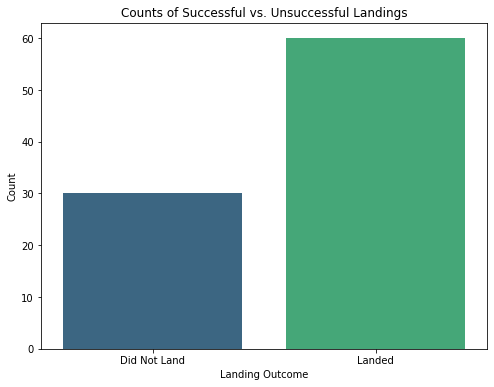

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each class (successful vs. unsuccessful landings)
class_counts = data['Class'].value_counts()

# Plotting the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Counts of Successful vs. Unsuccessful Landings')
plt.xlabel('Landing Outcome')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Did Not Land', 'Landed'])  # Adjust labels if necessary
plt.show()


In [ ]:
from threading import Thread
from dash import Dash, dcc, html, Input, Output
import pandas as pd
import numpy as np
import requests  # For fetching data
import io  # For StringIO
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import plotly.graph_objects as go

# Initialize the Dash app
app = Dash(__name__)

# Fetching the data from URL
URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
response = requests.get(URL1)

# Load the data into a pandas DataFrame
if response.status_code == 200:
    data = pd.read_csv(io.StringIO(response.text))
else:
    raise Exception(f"Failed to fetch data: {response.status_code}")

# Preprocess the data
Y = data['Class'].to_numpy()
X = data.drop(columns=['Class', 'Date', 'BoosterVersion', 'LandingPad', 'Outcome'])
X = pd.get_dummies(X, drop_first=True)
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# Train models and store performance metrics
models = {
    'Logistic Regression': (LogisticRegression(), {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}),
    'Support Vector Machine': (SVC(), {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'), 'C': np.logspace(-3, 3, 5), 'gamma': np.logspace(-3, 3, 5)}),
    'Decision Tree': (DecisionTreeClassifier(), {
        'criterion': ['gini', 'entropy'],
        'splitter': ['best', 'random'],
        'max_depth': [2 * n for n in range(1, 10)],
        'max_features': ['auto', 'sqrt'],
        'min_samples_leaf': [1, 2, 4],
        'min_samples_split': [2, 5, 10]
    }),
    'K-Nearest Neighbors': (KNeighborsClassifier(), {
        'n_neighbors': range(1, 11),  # Simplified using range
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
        'p': [1, 2]
    })
}

results = {}

for model_name, (model, params) in models.items():
    grid_search = GridSearchCV(estimator=model, param_grid=params, cv=5)
    grid_search.fit(X_train, Y_train)
    yhat = grid_search.predict(X_test)
    accuracy = grid_search.score(X_test, Y_test)
    results[model_name] = {
        'Best Params': grid_search.best_params_,
        'Accuracy': accuracy,
        'Confusion Matrix': confusion_matrix(Y_test, yhat),
        'Classification Report': classification_report(Y_test, yhat, output_dict=True)
    }

# Create confusion matrix plots
def create_confusion_matrix_plot(cm, model_name):
    fig = go.Figure(data=go.Heatmap(
        z=cm,
        x=['Predicted Landed', 'Predicted Not Landed'],
        y=['Actual Landed', 'Actual Not Landed'],
        colorscale='Viridis'
    ))
    fig.update_layout(title=f'Confusion Matrix for {model_name}', xaxis_title='Predicted', yaxis_title='Actual')
    return fig

# App layout
app.layout = html.Div([
    html.H1("Rocket Landing Prediction Models Dashboard"),
    
    dcc.Dropdown(
        id='model-dropdown',
        options=[{'label': model_name, 'value': model_name} for model_name in results.keys()],
        value='Logistic Regression',
        clearable=False
    ),
    
    html.Div(id='model-details'),
    dcc.Graph(id='confusion-matrix'),
])

# Callbacks to update the dashboard
@app.callback(
    Output('model-details', 'children'),
    Output('confusion-matrix', 'figure'),
    Input('model-dropdown', 'value')
)
def update_output(selected_model):
    model_result = results[selected_model]
    accuracy = model_result['Accuracy']
    best_params = model_result['Best Params']
    
    details = html.Div([
        html.H3(f"{selected_model}"),
        html.P(f"Accuracy: {accuracy:.2f}"),
        html.P(f"Best Parameters: {best_params}"),
    ])
    
    cm_plot = create_confusion_matrix_plot(model_result['Confusion Matrix'], selected_model)
    
    return details, cm_plot

# Function to run the Dash app in a separate thread
def run_dash():
    app.run_server(debug=True)

# Start the Dash app in a separate thread
thread = Thread(target=run_dash)
thread.start()

# Print message indicating the app is starting
print("Starting the Dash app...")

# Wait for the thread to finish if needed (not necessary here)
thread.join()


In [1]:
pip install dash pandas numpy scikit-learn plotly requests


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
from threading import Thread
from dash import Dash, dcc, html, Input, Output
import pandas as pd
import numpy as np
import requests  # For fetching data
import io  # For StringIO
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import plotly.graph_objects as go

# Initialize the Dash app
app = Dash(__name__)

# Fetching the data from URL
URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
response = requests.get(URL1)

# Load the data into a pandas DataFrame
if response.status_code == 200:
    data = pd.read_csv(io.StringIO(response.text))
else:
    raise Exception(f"Failed to fetch data: {response.status_code}")

# Preprocess the data
Y = data['Class'].to_numpy()
X = data.drop(columns=['Class', 'Date', 'BoosterVersion', 'LandingPad', 'Outcome'])
X = pd.get_dummies(X, drop_first=True)
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# Train models and store performance metrics
models = {
    'Logistic Regression': (LogisticRegression(), {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}),
    'Support Vector Machine': (SVC(), {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'), 'C': np.logspace(-3, 3, 5), 'gamma': np.logspace(-3, 3, 5)}),
    'Decision Tree': (DecisionTreeClassifier(), {
        'criterion': ['gini', 'entropy'],
        'splitter': ['best', 'random'],
        'max_depth': [2 * n for n in range(1, 10)],
        'max_features': ['auto', 'sqrt'],
        'min_samples_leaf': [1, 2, 4],
        'min_samples_split': [2, 5, 10]
    }),
    'K-Nearest Neighbors': (KNeighborsClassifier(), {
        'n_neighbors': range(1, 11),  # Simplified using range
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
        'p': [1, 2]
    })
}

results = {}

for model_name, (model, params) in models.items():
    grid_search = GridSearchCV(estimator=model, param_grid=params, cv=5)
    grid_search.fit(X_train, Y_train)
    yhat = grid_search.predict(X_test)
    accuracy = grid_search.score(X_test, Y_test)
    results[model_name] = {
        'Best Params': grid_search.best_params_,
        'Accuracy': accuracy,
        'Confusion Matrix': confusion_matrix(Y_test, yhat),
        'Classification Report': classification_report(Y_test, yhat, output_dict=True)
    }

# Create confusion matrix plots
def create_confusion_matrix_plot(cm, model_name):
    fig = go.Figure(data=go.Heatmap(
        z=cm,
        x=['Predicted Landed', 'Predicted Not Landed'],
        y=['Actual Landed', 'Actual Not Landed'],
        colorscale='Viridis'
    ))
    fig.update_layout(title=f'Confusion Matrix for {model_name}', xaxis_title='Predicted', yaxis_title='Actual')
    return fig

# App layout
app.layout = html.Div([
    html.H1("Rocket Landing Prediction Models Dashboard"),
    
    dcc.Dropdown(
        id='model-dropdown',
        options=[{'label': model_name, 'value': model_name} for model_name in results.keys()],
        value='Logistic Regression',
        clearable=False
    ),
    
    html.Div(id='model-details'),
    dcc.Graph(id='confusion-matrix'),
])

# Callbacks to update the dashboard
@app.callback(
    Output('model-details', 'children'),
    Output('confusion-matrix', 'figure'),
    Input('model-dropdown', 'value')
)
def update_output(selected_model):
    model_result = results[selected_model]
    accuracy = model_result['Accuracy']
    best_params = model_result['Best Params']
    
    details = html.Div([
        html.H3(f"{selected_model}"),
        html.P(f"Accuracy: {accuracy:.2f}"),
        html.P(f"Best Parameters: {best_params}"),
    ])
    
    cm_plot = create_confusion_matrix_plot(model_result['Confusion Matrix'], selected_model)
    
    return details, cm_plot

# Run the app in a separate thread
def run_dash():
    app.run_server(debug=True)

if __name__ == '__main__':
    # Start the Dash app in a separate thread
    thread = Thread(target=run_dash)
    thread.start()
    print("Starting the Dash app...")


Starting the Dash app...


In [7]:
from threading import Thread
from dash import Dash, dcc, html, Input, Output
import pandas as pd
import numpy as np
import requests  # For fetching data
import io  # For StringIO
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import plotly.graph_objects as go
import folium

# Initialize the Dash app
app = Dash(__name__)

# Fetching the data from URL
URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
response = requests.get(URL1)

# Load the data into a pandas DataFrame
if response.status_code == 200:
    data = pd.read_csv(io.StringIO(response.text))
else:
    raise Exception(f"Failed to fetch data: {response.status_code}")

# Preprocess the data
Y = data['Class'].to_numpy()
X = data.drop(columns=['Class', 'Date', 'BoosterVersion', 'LandingPad', 'Outcome'])
X = pd.get_dummies(X, drop_first=True)
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# Train models and store performance metrics
results = {}  # Initialize results dictionary

models = {
    'Logistic Regression': (LogisticRegression(), {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}),
    'Support Vector Machine': (SVC(), {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'), 'C': np.logspace(-3, 3, 5), 'gamma': np.logspace(-3, 3, 5)}),
    'Decision Tree': (DecisionTreeClassifier(), {
        'criterion': ['gini', 'entropy'],
        'splitter': ['best', 'random'],
        'max_depth': [2 * n for n in range(1, 10)],
        'max_features': ['auto', 'sqrt'],
        'min_samples_leaf': [1, 2, 4],
        'min_samples_split': [2, 5, 10]
    }),
    'K-Nearest Neighbors': (KNeighborsClassifier(), {
        'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
        'p': [1, 2]
    })
}

for model_name, (model, params) in models.items():
    grid_search = GridSearchCV(estimator=model, param_grid=params, cv=5)
    grid_search.fit(X_train, Y_train)
    yhat = grid_search.predict(X_test)
    accuracy = grid_search.score(X_test, Y_test)
    results[model_name] = {
        'Best Params': grid_search.best_params_,
        'Accuracy': accuracy,
        'Confusion Matrix': confusion_matrix(Y_test, yhat),
        'Classification Report': classification_report(Y_test, yhat, output_dict=True)
    }

# Create confusion matrix plots
def create_confusion_matrix_plot(cm, model_name):
    fig = go.Figure(data=go.Heatmap(
        z=cm,
        x=['Predicted Landed', 'Predicted Not Landed'],
        y=['Actual Landed', 'Actual Not Landed'],
        colorscale='Viridis'
    ))
    fig.update_layout(title=f'Confusion Matrix for {model_name}', xaxis_title='Predicted', yaxis_title='Actual')
    return fig

# Create Folium map function
def create_folium_map(data):
    # Create a map centered at a specific location
    folium_map = folium.Map(location=[data['Latitude'].mean(), data['Longitude'].mean()], zoom_start=5)

    # Add markers for each landing location
    for _, row in data.iterrows():
        color = 'green' if row['Class'] == 'Success' else 'red'
        folium.Marker(
            location=[row['Latitude'], row['Longitude']],
            popup=f"{row['LandingPad']}: {row['Class']}",
            icon=folium.Icon(color=color)
        ).add_to(folium_map)

    # Add a layer control
    folium.LayerControl().add_to(folium_map)
    return folium_map

# Create the Folium map with landing data
folium_map = create_folium_map(data)

# Save the Folium map to an HTML file
folium_map.save('landing_map.html')

# App layout
app.layout = html.Div([
    html.H1("Rocket Landing Prediction Models Dashboard"),
    
    dcc.Dropdown(
        id='model-dropdown',
        options=[{'label': model_name, 'value': model_name} for model_name in results.keys()],
        value='Logistic Regression',
        clearable=False
    ),
    
    html.Div(id='model-details'),
    dcc.Graph(id='confusion-matrix'),

    # Display Folium map
    html.Iframe(src='landing_map.html', style={'width': '100%', 'height': '600px'})
])

# Callbacks to update the dashboard
@app.callback(
    Output('model-details', 'children'),
    Output('confusion-matrix', 'figure'),
    Input('model-dropdown', 'value')
)
def update_output(selected_model):
    model_result = results[selected_model]
    accuracy = model_result['Accuracy']
    best_params = model_result['Best Params']
    
    details = html.Div([
        html.H3(f"{selected_model}"),
        html.P(f"Accuracy: {accuracy:.2f}"),
        html.P(f"Best Parameters: {best_params}"),
    ])
    
    cm_plot = create_confusion_matrix_plot(model_result['Confusion Matrix'], selected_model)
    
    return details, cm_plot

# Run the app in a separate thread
def run_dash():
    app.run_server(debug=True)

if __name__ == '__main__':
    # Start the Dash app in a separate thread
    thread = Thread(target=run_dash)
    thread.start()
    print("Starting the Dash app...")


Starting the Dash app...


In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import requests  # For fetching data
import io  # For StringIO
from dash import Dash, dcc, html
import plotly.express as px

# Fetching the data from URL using requests
URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
response = requests.get(URL1)

# Check if the request was successful
if response.status_code == 200:
    # Load the data into a pandas DataFrame
    data = pd.read_csv(io.StringIO(response.text))
    print(data.head())  # Display first few rows of the dataset

    # Create the target variable Y from the 'Class' column
    Y = data['Class'].to_numpy()

    # Preprocess the features
    # Dropping non-numeric columns
    X = data.drop(columns=['Class', 'Date', 'BoosterVersion', 'LandingPad', 'Outcome'])

    # One-hot encoding for categorical variables
    X = pd.get_dummies(X, drop_first=True)

    # Preprocess the features (Standardization)
    transform = preprocessing.StandardScaler()
    X = transform.fit_transform(X)

    # Split the data into training and test sets
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

    # Analyze successes and failures of each launch site
    data['Success'] = data['Class'].apply(lambda x: 'Success' if x == 1 else 'Failure')
    launch_summary = data.groupby('LaunchSite')['Success'].value_counts().unstack(fill_value=0)
    
    # Prepare data for pie chart
    launch_summary = launch_summary.reset_index()
    
    # Create Dash app
    app = Dash(__name__)

    # Layout of the app
    app.layout = html.Div([
        html.H1("Launch Successes and Failures by Site"),
        dcc.Graph(
            id='pie-chart',
            figure=px.pie(launch_summary,
                           values=launch_summary['Success'],
                           names=launch_summary['LaunchSite'],
                           title='Successes and Failures of Launch Sites',
                           color_discrete_sequence=px.colors.qualitative.Plotly)
        )
    ])

    # Run the app
    if __name__ == '__main__':
        app.run_server(debug=True)

else:
    print(f"Failed to fetch data: {response.status_code}")


   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40   
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40   
3             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E   
4             5  2013-12-03       Falcon 9  3170.000000   GTO  CCAFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
0    None None        1     False   False  False        NaN    1.0   
1    None None        1     False   False  False        NaN    1.0   
2    None None        1     False   False  False        NaN    1.0   
3  False Ocean        1     False   False  False        NaN    1.0   
4    None None        1     False   False  False        NaN    1.0   

   ReusedCount Serial   Longitude   Latitude  Class  
0            0  B0003  -80.577366  28.561857      

In [17]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import base64
import io
from sklearn.datasets import load_iris

# Load example dataset (replace this with your actual dataset)
data = load_iris(as_frame=True)
df = data['frame']
X = df.drop(columns=['target'])
y = df['target']

# Preprocessing
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Dash app
app = dash.Dash(__name__)

def model_training():
    models = {
        "Logistic Regression": (LogisticRegression(), {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}),
        "SVM": (SVC(), {'kernel': ['linear', 'rbf'], 'C': np.logspace(-3, 3, 5), 'gamma': np.logspace(-3, 3, 5)}),
        "Decision Tree": (DecisionTreeClassifier(), {
            'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 7]}),
        "KNN": (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7], 'algorithm': ['auto'], 'p': [1, 2]})
    }
    results = {}
    images = {}

    for model_name, (model, params) in models.items():
        grid = GridSearchCV(model, params, cv=5)
        grid.fit(X_train, y_train)
        y_pred = grid.predict(X_test)
        
        # Store results
        results[model_name] = {
            "Best Params": grid.best_params_,
            "Validation Accuracy": grid.best_score_,
            "Classification Report": classification_report(y_test, y_pred, output_dict=True)
        }

        # Confusion Matrix plot
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)
        plt.xlabel('Predicted Labels')
        plt.ylabel('True Labels')
        plt.title(f'{model_name} - Confusion Matrix')
        
        # Save plot to image buffer
        buffer = io.BytesIO()
        plt.savefig(buffer, format="png")
        buffer.seek(0)
        images[model_name] = base64.b64encode(buffer.getvalue()).decode()
        plt.close()

    return results, images

# Run model training and store results
model_results, model_images = model_training()

# Layout
app.layout = html.Div([
    html.H1("Model Performance Summary"),
    html.Div([
        html.Div([
            html.H2(f"{model_name}"),
            html.P(f"Best Parameters: {result['Best Params']}"),
            html.P(f"Validation Accuracy: {result['Validation Accuracy']:.2f}"),
            html.Img(src=f"data:image/png;base64,{model_images[model_name]}", style={'width': '50%'})
        ], style={'border': '1px solid black', 'padding': '10px', 'margin': '10px'})
        for model_name, result in model_results.items()
    ])
])

# Run the app
if __name__ == '__main__':
    app.run_server(debug=True)
